In [1]:
import rasterio
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ruta = "data/NDVI_CABA.tif"

with rasterio.open("data/NDVI_CABA.tif") as src:
    ndvi = src.read(1)
    ndvi = np.where(ndvi == src.nodata, np.nan, ndvi)
    transform = src.transform
    res_x, res_y = src.res

print("Resolución horizontal:", res_x)
print("Resolución vertical:", res_y)

Resolución horizontal: 10.0
Resolución vertical: 10.0


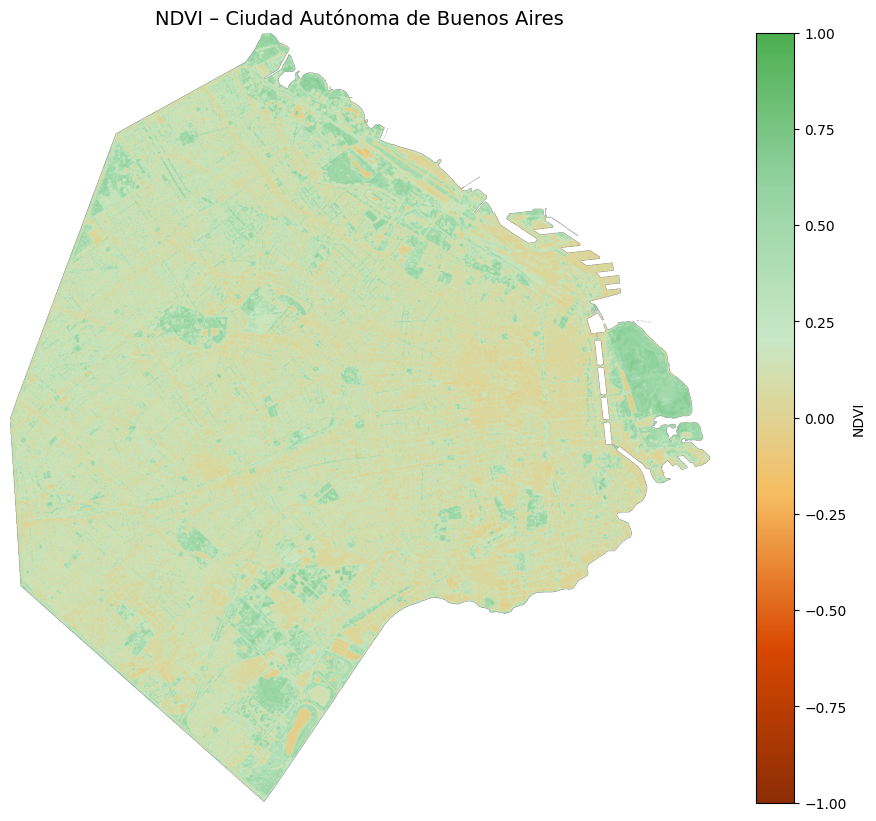

In [2]:
ndvi_neg_pos_contraste = LinearSegmentedColormap.from_list(
    "ndvi_neg_pos_contraste",
    [
        "#8c2d04",  # marrón/rojizo oscuro para NDVI muy negativo (-1)
        "#d94801",  # naranja con contraste (-0.5)
        "#f6bd60",  # amarillo suave para ~0
        "#c9e8c5",  # verde pastel claro (+0.2)
        "#94d3a2",  # verde pastel medio (+0.5)
        "#4caf50",  # verde natural (+1)
    ]
)

plt.figure(figsize=(12, 10))

plt.imshow(ndvi, cmap=ndvi_neg_pos_contraste, vmin=-1, vmax=1)
plt.title("NDVI – Ciudad Autónoma de Buenos Aires", fontsize=14)
plt.colorbar(label="NDVI")
plt.axis("off")

plt.show()

In [3]:
radius_m = 80
sigma_m  = radius_m / 3     # 100 m

radius_px = int(radius_m / res_x)
sigma_px  = sigma_m / res_x

In [4]:
# Coordenadas del kernel
yy, xx = np.ogrid[-radius_px:radius_px+1, -radius_px:radius_px+1]
dist_sq = xx**2 + yy**2

# Kernel gaussiano
kernel = np.exp(-(dist_sq) / (2 * sigma_px**2))

In [5]:
mask = dist_sq <= (radius_px**2)
kernel = kernel * mask

# Normalizamos para estabilidad numérica (no obligatorio):

kernel = kernel / kernel.sum()

In [6]:
valid_mask = ~np.isnan(ndvi)

# NDVI con NaN tratados como 0 temporalmente
ndvi_filled = np.nan_to_num(ndvi, nan=0.0)

# Suma ponderada local
local_weighted_sum = convolve2d(ndvi_filled, kernel, mode="same", boundary="symm")

# Suma de pesos válidos (normalización por pixeles válidos)
local_weights_sum = convolve2d(valid_mask.astype(float), kernel, mode="same", boundary="symm")

In [7]:
X = ndvi[valid_mask]
X_bar = np.mean(X)
S = np.std(X, ddof=1)
n = len(X)

In [8]:
kernel_sq = kernel**2

local_sum = local_weighted_sum                   # suma w_ij * x_j
local_w1  = local_weights_sum                    # suma w_ij
local_w2  = convolve2d(valid_mask.astype(float), kernel_sq, mode="same", boundary="symm")  # suma w_ij^2


In [9]:
Gi_star = (
    local_sum - X_bar * local_w1
) / (
    S * np.sqrt((n * local_w2 - local_w1**2) / (n - 1))
)


C:\Users\tomas\AppData\Local\Temp\ipykernel_11952\1101452197.py:1: RuntimeWarning: invalid value encountered in divide
  Gi_star = (


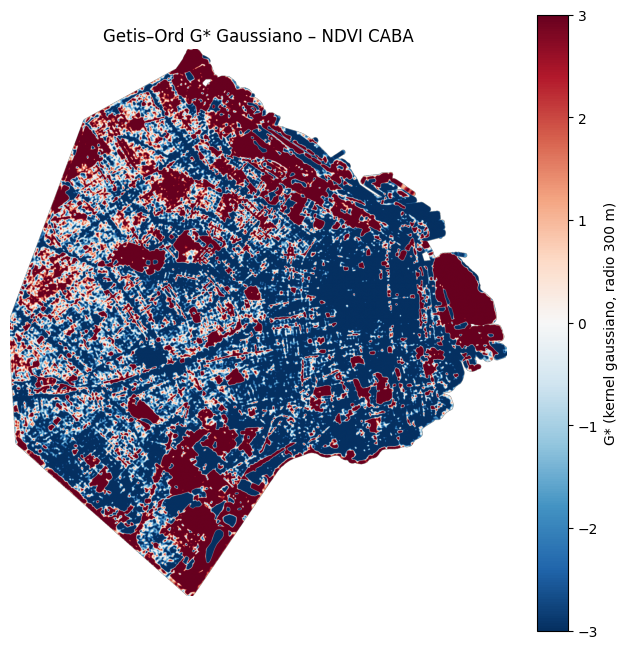

In [10]:
plt.figure(figsize=(8,8))
plt.imshow(Gi_star, cmap="RdBu_r", vmin=-3, vmax=3)
plt.colorbar(label="G* (kernel gaussiano, radio 300 m)")
plt.title("Getis–Ord G* Gaussiano – NDVI CABA")
plt.axis("off")
plt.show()


In [11]:
Gi = Gi_star.copy()

# Opcional: enmascarar donde no hay datos originales
Gi[~valid_mask] = np.nan

# Umbrales clásicos (normal estándar)
alpha = 0.05   # bilateral
z_crit = 1.96  # para 5% (~2.58 para 1%)

hot  = (Gi >  z_crit)
cold = (Gi < -z_crit)
ns   = ~(hot | cold)

In [12]:
clase = np.full(Gi.shape, "ns", dtype=object)
clase[hot]  = "hot"
clase[cold] = "cold"

C:\Users\tomas\AppData\Local\Temp\ipykernel_11952\148556581.py:21: RuntimeWarning: invalid value encountered in divide
  Gi_star = (


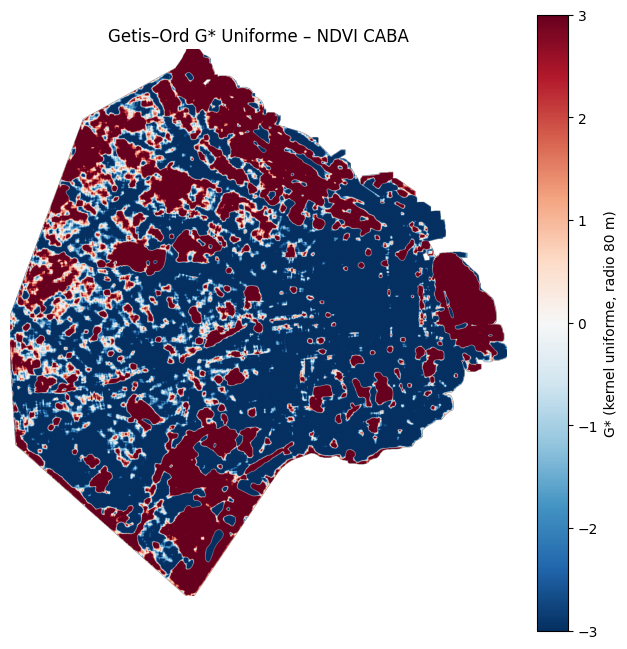

In [14]:
# este se ve demasiado pintado, todo es o hot o coldspot y eso no tiene sentido, por eso lo que ahre ahoa sera hacer es probar con un kernel uniforme
radius_m = 80
radius_px = int(radius_m / res_x)
kernel = np.ones((2*radius_px+1, 2*radius_px+1))
kernel = kernel / kernel.sum()
valid_mask = ~np.isnan(ndvi)
# NDVI con NaN tratados como 0 temporalmente
ndvi_filled = np.nan_to_num(ndvi, nan=0.0)
# Suma ponderada local
local_weighted_sum = convolve2d(ndvi_filled, kernel, mode="same", boundary="symm")
# Suma de pesos válidos (normalización por pixeles válidos)
local_weights_sum = convolve2d(valid_mask.astype(float), kernel, mode="same", boundary="symm")
X = ndvi[valid_mask]
X_bar = np.mean(X)
S = np.std(X, ddof=1)
n = len(X)
kernel_sq = kernel**2
local_sum = local_weighted_sum                   # suma w_ij * x_j
local_w1  = local_weights_sum                    # suma w_ij
local_w2  = convolve2d(valid_mask.astype(float), kernel_sq, mode="same", boundary="symm")  # suma w_ij^2
Gi_star = (
    local_sum - X_bar * local_w1
) / (
    S * np.sqrt((n * local_w2 - local_w1**2) / (n - 1))
)
plt.figure(figsize=(8,8))
plt.imshow(Gi_star, cmap="RdBu_r", vmin=-3, vmax=3)
plt.colorbar(label="G* (kernel uniforme, radio 80 m)")
plt.title("Getis–Ord G* Uniforme – NDVI CABA")
plt.axis("off")
plt.show()